In [8]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Network

## Template 03
## FIFA dataset Using TENSORFLOW


<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [9]:
###-----------------
### Import libraries
###-----------------
import sys
from pathlib import Path

# Add current directory to path for local imports
sys.path.insert(0, str(Path.cwd()))

import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler, LabelEncoder  # Import for standardizing features (zero mean, unit variance)

# from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix # Custom utility 
import tensorflow as tf
import pydot


In [10]:
import pydot
print(pydot.__version__)  # check what version you have

# Correct verification for pydot v2.x
graphs = pydot.graph_from_dot_data('digraph { a -> b }')
print(graphs)  # if this returns a list (not None/error), graphviz is found

4.0.1


In [11]:
# print (fn_plot_torch_hist.__doc__)

In [12]:
# print (fn_plot_confusion_matrix.__doc__)

In [13]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'
subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 101 # number of epochs
BATCH_SIZE = 32
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2

# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## Basic Hygiene

In [14]:
# Check if all directories are present
outDir.mkdir(parents=True, exist_ok=True)

modelSubDir = modelDir/ subDir
modelSubDir.mkdir(parents=True, exist_ok=True)

## Read FIFA 2019 data set

In [15]:
data_df = pd.read_csv('D:/Deep_Learning/SharedData/fifa_2019.csv')
data_df.shape

(18207, 89)

In [16]:
# removing rows with position = null
data_df = data_df[data_df["Position"].notnull()]
data_df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [17]:
# Following columns appear to be relevant for our analysis
rel_cols = ["Position", 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
            'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
            'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
            'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
            'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
            'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
            'GKKicking', 'GKPositioning', 'GKReflexes']

In [18]:
goalkeeper = 'GK'
forward = ['ST', 'LW', 'RW', 'LF', 'RF', 'RS','LS', 'CF']
midfielder = ['CM','RCM','LCM', 'CDM','RDM','LDM', 'CAM', 'LAM', 'RAM', 'RM', 'LM']
defender = ['CB', 'RCB', 'LCB', 'LWB', 'RWB', 'LB', 'RB']

In [19]:
data_df = data_df[rel_cols]
data_df.head()

,Position,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,RF,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,...,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0
1,ST,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,...,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0
2,LW,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,...,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0
3,GK,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,...,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0
4,RCM,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,...,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0


In [20]:
#Assign labels to goalkeepers

data_df['Position_encoded'] = 0

data_df.loc[data_df["Position"] == "GK", "Position"] = 0

#Defenders
data_df.loc[data_df["Position"].isin(defender), "Position"] = 1

#Midfielders
data_df.loc[data_df["Position"].isin(midfielder), "Position"] = 2

#Forward
data_df.loc[data_df["Position"].isin(forward), "Position"] = 3

# Convert Column "Position" to numeric so that Pandas does not complain
data_df['Position_encoded'] = pd.to_numeric(data_df['Position'], downcast="integer")

In [21]:
data_df['Position_encoded']

0        3
1        3
2        3
3        0
4        2
        ..
18202    2
18203    3
18204    3
18205    3
18206    2
Name: Position_encoded, Length: 18147, dtype: int8

In [22]:
labels = data_df['Position_encoded']
features = data_df.drop(['Position', 'Position_encoded'], axis = 1)

In [23]:
class_names = {0: 'Goal Keeper', 1: 'Defender', 2: 'Mid-Fielder', 3: 'Forward'}

In [24]:
# splitting in train ans test datasets
X_train,X_test,y_train,y_test = train_test_split(features,labels,
                                     stratify=labels,
                                     test_size=TEST_SIZE, 
                                     random_state=RANDOM_STATE )

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((14517, 33), (14517,), (3630, 33), (3630,))

In [25]:
list(class_names.keys())

[0, 1, 2, 3]

In [26]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train.to_numpy(), 
                                               y_train.to_numpy()))

test_ds = tf.data.Dataset.from_tensor_slices((X_test.to_numpy(),
                                              y_test.to_numpy()))

type(train_ds), type(test_ds)

(tensorflow.python.data.ops.from_tensor_slices_op._TensorSliceDataset,
 tensorflow.python.data.ops.from_tensor_slices_op._TensorSliceDataset)

## Preprocessing and Batching

In [27]:
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.cache()
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [28]:
train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE)

test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)

In [29]:
train_ds    # just an object

<_BatchDataset element_spec=(TensorSpec(shape=(None, 33), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.int8, name=None))>

In [30]:
for features, labels in train_ds.take(1):
    print(features.shape, labels.shape) 

(32, 33) (32,)


## Normalization of data in Tensorflow

In [31]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train.to_numpy())

In [32]:
normalizer.mean.numpy()

array([[45.520493, 52.243782, 58.685886, 42.902115, 55.379074, 47.15747 ,
        42.83013 , 52.761726, 58.392986, 64.649925, 64.79913 , 63.53792 ,
        61.809742, 63.964455, 55.430115, 65.06902 , 63.24902 , 65.372665,
        47.119926, 55.8727  , 46.72701 , 49.943306, 53.40263 , 48.518635,
        58.645657, 47.280293, 47.679203, 45.641525, 16.618792, 16.377558,
        16.216711, 16.372667, 16.711098]], dtype=float32)

In [33]:
normalizer.variance.numpy()

array([[381.27637, 302.225  , 216.46509, 314.4344 , 358.05862, 338.72565,
        305.6274 , 233.78761, 277.84177, 220.56754, 213.31131, 217.05934,
         81.14435, 199.90918, 297.45694, 139.75758, 252.52716, 157.12006,
        371.17862, 301.67438, 426.03412, 381.6611 , 201.29845, 245.74033,
        130.18896, 396.54602, 468.74197, 451.3309 , 312.67398, 285.4781 ,
        271.2175 , 288.47983, 321.72186]], dtype=float32)

In [34]:
inputs = tf.keras.Input(shape=(X_train.shape[1],), name='input')

x = normalizer(inputs)

x = tf.keras.layers.Dense(16, activation='relu')(x)    # alternative = tf.nn.relu
x = tf.keras.layers.Dense(8, activation='relu')(x)   

outputs = tf.keras.layers.Dense(4)(x)   

model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [35]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 33)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 33)             │            67 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 783 (3.06 KB)

 Trainable params: 716 (2.80 KB)

 Non-trainable params: 67 (272.00 B)

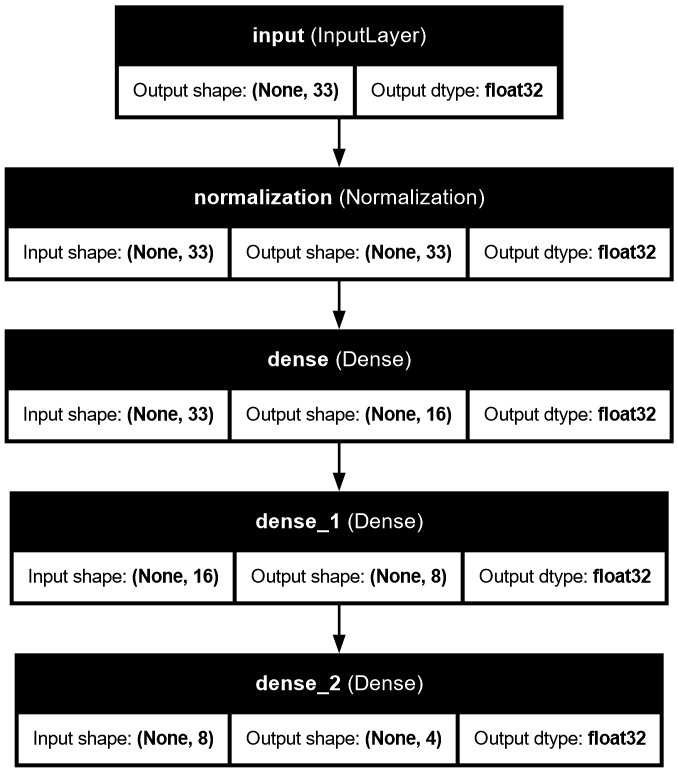

In [36]:
tf.keras.utils.plot_model(model,
                          to_file=modelSubDir/'tf_FIFA.png',
                          show_shapes=True, 
                          show_layer_names=True, 
                          dpi=96, 
                          show_dtype=True, 
                          expand_nested=True)

In [37]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)

model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

history = model.fit(train_ds,
                    validation_data=test_ds,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE)

Epoch 1/101


454/454 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7307 - loss: 0.6709 - val_accuracy: 0.8353 - val_loss: 0.3754
Epoch 2/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8573 - loss: 0.3430 - val_accuracy: 0.8592 - val_loss: 0.3301
Epoch 3/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8717 - loss: 0.3200 - val_accuracy: 0.8642 - val_loss: 0.3179
Epoch 4/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8744 - loss: 0.3093 - val_accuracy: 0.8727 - val_loss: 0.3121
Epoch 5/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8762 - loss: 0.3032 - val_accuracy: 0.8694 - val_loss: 0.3103
Epoch 6/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8771 - loss: 0.2983 - val_accuracy: 0.8725 - val_loss: 0.3051
Epoch 7/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8790 - loss: 0.2949 - val_accuracy: 0.8697 - val_loss: 0.3068
Epoch 8/101
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8799 - loss: 0.2923 - val_accuracy: 0.8727

In [38]:
loss_df = pd.DataFrame(history.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.730729,0.670924,0.835262,0.375352
1,0.857271,0.343008,0.859229,0.330059
2,0.871737,0.320049,0.864187,0.317921
3,0.874354,0.309315,0.872727,0.312130
4,0.876214,0.303210,0.869421,0.310262


In [39]:
def fn_plot_tf_hist(hist_df):
    fig,axes=plt.subplots(1,2,figsize=(15,6))
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    
    facecolor='cyan'
    fontsize=12
    cmap=plt.cm.coolwarm
    
     # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]
    
    best = hist_df[hist_df['val_loss']==hist_df['val_loss'].min()]
    
    best_idx = best.index.to_numpy()[0]
    best_loss = best['val_loss'].to_numpy()[0]
    
    ax = axes[0]
    loss_df[['loss', 'val_loss']].plot(ax=ax,colormap=cmap)
    
    txtFmt = 'Loss:\n train:{:6.4f}\n test:{:6.4f}'
    
    txtstr = txtFmt.format(hist_df.iloc[-1]['loss'], 
                           hist_df.iloc[-1]['val_loss'])
    
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
           verticalalignment='top', bbox=props)
    
    ax.annotate(f'Min:{best_loss}', xy = {best_idx, best_loss},
                xytext = (best_idx, best_loss+0.1), fontsize = fontsize,
                bbox = props, arrowprops = dict(facecolor = facecolor, shrink=0.05))
    
    ax.axvline(x = best_idx, color = 'green', lw=3, linestyle= '-.')
    
    
    ax = axes[1]
    best_acc = best['val_accuracy'].to_numpy()[0]
    
    hist_df[['accuracy', 'val_accuracy']].plot(ax=ax, colormap=cmap)
    
    txtfmt = 'Accuracy:\n train:{:6.4f}\n test:{:6.4f}'
    
    txtstr = txtfmt.format(hist_df.iloc[-1]['accuracy'], 
                           hist_df.iloc[-1]['val_accuracy'])
    
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
           verticalalignment='top', bbox=props)
    
    ax.annotate(f'Min:{best_acc}', xy = {best_idx, best_acc},
                xytext = (best_idx, best_acc+0.1), fontsize = fontsize,
                bbox = props, arrowprops = dict(facecolor = facecolor, shrink=0.05))
    
    ax.axvline(x = best_idx, color = 'green', lw=3, linestyle= '-.')

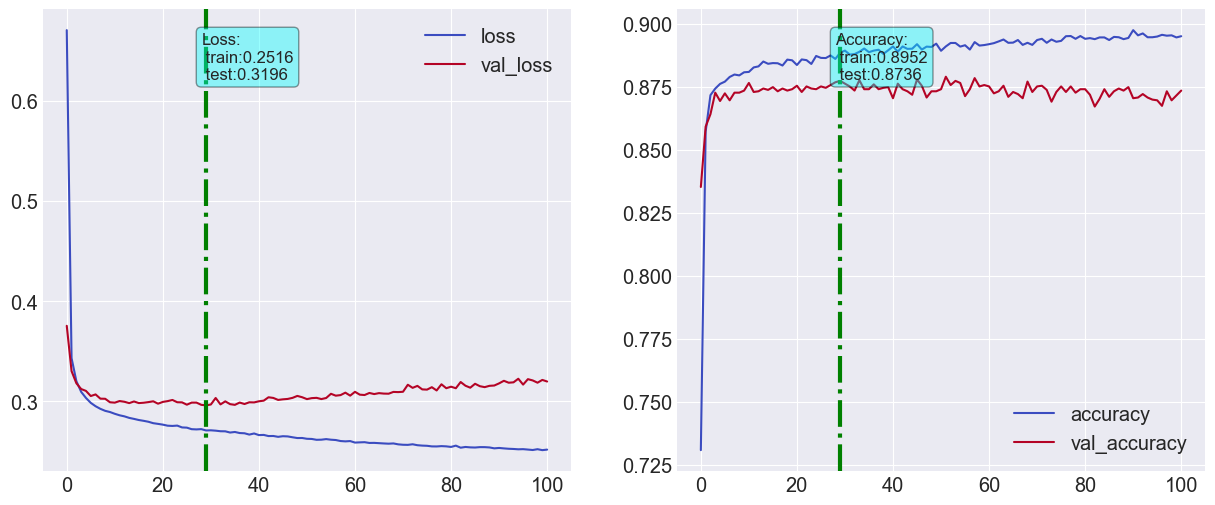

In [40]:
fn_plot_tf_hist(loss_df)

## Feature Importance

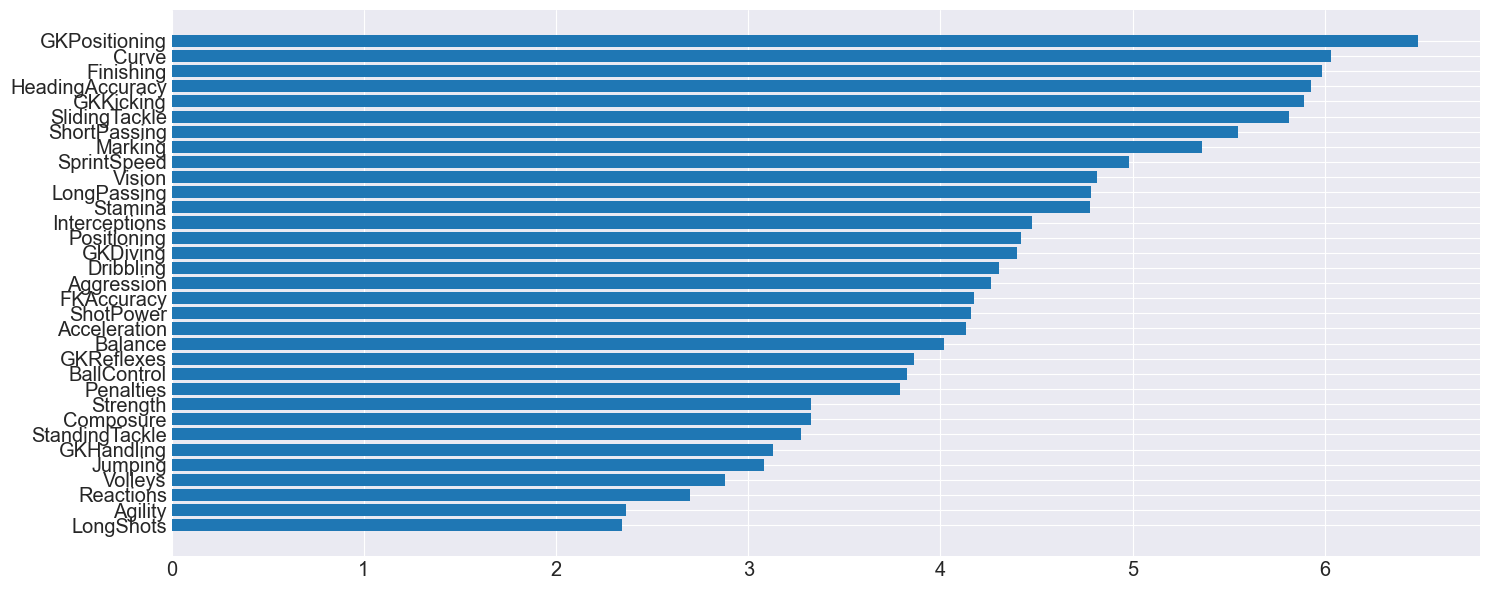

In [41]:
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        first_kernel = layer
        break
    
weights, bias = first_kernel.get_weights()
weights.shape, bias.shape

features_importance = np.abs(weights).sum(axis=1)
features_df = pd.DataFrame({'feature': X_train.columns, 
                            'importance': features_importance})

features_df = features_df.sort_values(by='importance', ascending=False)

fig, ax = plt.subplots()
ax.barh(features_df['feature'], features_df['importance'])
plt.gca().invert_yaxis()
plt.tight_layout()

In [42]:
y_true, y_pred = [], []

for features, labels in train_ds:
    pred = model(features, training=False)
    pred = pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())
    
y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

accuracy_score(y_true, y_pred)

0.8980505614107598

In [43]:
print(classification_report(y_true, y_pred, target_names=list(class_names.values())))

              precision    recall  f1-score   support

 Goal Keeper       1.00      1.00      1.00      1620
    Defender       0.93      0.94      0.93      4693
 Mid-Fielder       0.84      0.90      0.87      5470
     Forward       0.90      0.77      0.83      2734

    accuracy                           0.90     14517
   macro avg       0.92      0.90      0.91     14517
weighted avg       0.90      0.90      0.90     14517



In [44]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    # Disable the grid
    ax.grid(False)
    ax.set_title(f"F1_Score: {f1_score(y_true, y_pred, average='weighted'):0.4f}")
    plt.show()

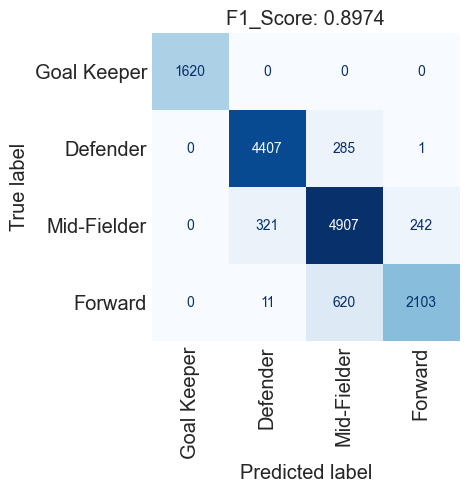

In [45]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_names)

## Predictions on test_ds

In [46]:
y_true, y_pred = [], []

for features, labels in test_ds:
    pred = model(features, training=False)
    pred = pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())
    
y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

accuracy_score(y_true, y_pred)

0.8735537190082645

In [47]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    # Disable the grid
    ax.grid(False)
    ax.set_title(f"F1_Score: {f1_score(y_true, y_pred, average='weighted'):0.4f}")
    plt.show()

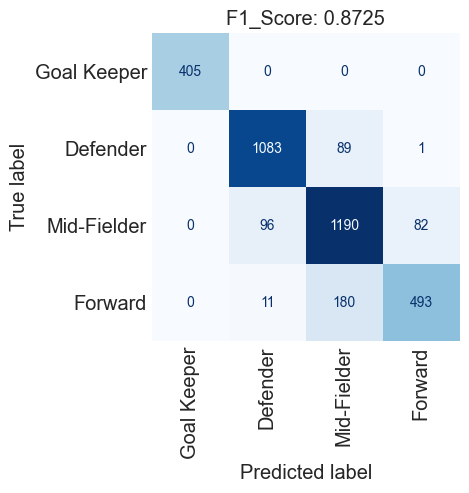

In [48]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_names)